In [52]:
!pip install pandas

In [53]:
!pip install sklearn

In [54]:
!pip install keras

In [55]:
from keras.preprocessing.image import ImageDataGenerator

In [56]:
import numpy as np
import math
import matplotlib.pyplot as plt
import shutil
import glob
import os

In [57]:
import cv2 
import pandas as pd 
from keras.models import Sequential, Model,load_model 
from pathlib import Path 
from keras.callbacks import Callback, EarlyStopping
from PIL import Image 
from keras.utils import to_categorical 
from sklearn.metrics import confusion_matrix 
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, Activation 
from keras.optimizers import Adam, SGD, RMSprop 
import tensorflow as tf 
import matplotlib.pyplot as plt
from keras import backend as K 

In [58]:
#!pip install pandas

In [59]:
from sklearn.metrics import plot_confusion_matrix

In [60]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.applications.vgg16 import decode_predictions
from keras.applications.vgg16 import VGG16
import numpy as np
import matplotlib.pyplot as plt

In [61]:
from tensorflow.keras.utils import load_img, img_to_array 
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, Activation 
from keras.optimizers import Adam, SGD, RMSprop 
from keras.callbacks import Callback, EarlyStopping
from keras.utils import to_categorical 
from sklearn.metrics import confusion_matrix 
from keras import backend as K 
import tensorflow as tf 
import matplotlib.pyplot as plt

In [62]:
#!pip install sklearn

In [63]:
# pip install -U scikit-learn scipy matplotlib

In [64]:
print(os.listdir("D:/research/data_test_train"))

['test', 'train', 'val']


In [65]:
data_dir = Path("D:/research/data_test_train")
train_folder = data_dir / 'train'
test_folder = data_dir / 'test'
validation_folder = data_dir / 'val'

In [66]:
def get_all_train_data_with_label():
    healthy_folder = train_folder / 'healthy'
    sick_folder = train_folder / 'sick'

    # List of all healthy and sick images
    normal_cases = healthy_folder.glob('*.jpg')
    sick_cases = sick_folder.glob('*.jpg')
    all_train_data = []
    train_label = []
    for image in normal_cases:
        all_train_data.append(image)
        train_label.append('healthy')
    for image in sick_cases:
        all_train_data.append(image)
        train_label.append('sick')
    df=pd.DataFrame(all_train_data)
    df.columns=['images']
    df['labels']=train_label
    df=df .sample(frac=1).reset_index(drop=True)
    return df

In [67]:
targer_train_data = get_all_train_data_with_label()
targer_train_data.shape

(4302, 2)

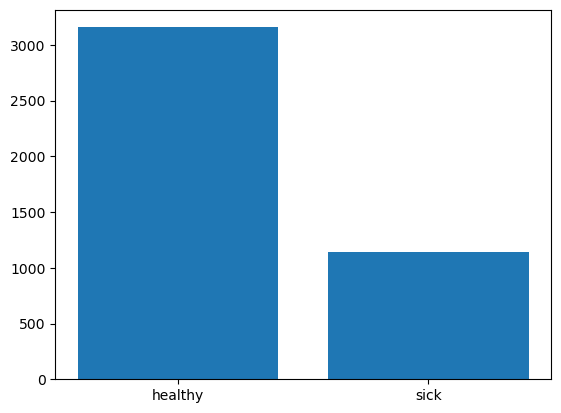

In [68]:
plt.bar(targer_train_data['labels'].value_counts().index, targer_train_data['labels'].value_counts().values)
plt.show()

In [70]:
from tensorflow.keras.preprocessing import image

100_13_dinamic_frontal.jpg


FileNotFoundError: [Errno 2] No such file or directory: '100_13_dinamic_frontal.jpg'

In [78]:
#image classification-Data preprocessing
def prepare_and_load(status=True):
    if status:
        normal_folder = validation_folder / 'healthy'
        sick_folder = validation_folder / 'sick'
    else:
        normal_folder = test_folder / 'healthy'
        sick_folder = test_folder / 'sick'
    normal_cases = normal_folder.glob('*.jpg')
    sick_cases = sick_folder.glob('*.jpg')
    data, label = ([] for x in range(2))

    def pre_processing(image_bundle):
        for image in image_bundle:
            image = cv2.imread(str(image))
            image = cv2.resize(image, (224, 224))
            if image.shape[2] == 1:
                image = np.dstack([image, image, image])
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = image.astype(np.float32) / 255.
            if image_bundle == normal_cases:
                sys_label = to_categorical(0, num_classes=2)
            else:
                sys_label = to_categorical(1, num_classes=2)
            data.append(image)
            sys_label.append(sys_label)
        return data, sys_label

    pre_processing(normal_cases)
    data, label = pre_processing(sick_cases)
    data = np.array(data)
    label = np.array(label)
    return data, label

In [81]:
val_data,val_labels= prepare_and_load(status=True)
test_data,test_labels= prepare_and_load(status=False)
print('Total test images: ', len(test_data))
print('Total train images: ', len(val_data))
print('Total validations image: ', len(targer_train_data))

Number of test images --> 616
Number of validation images--> 1229
Number of train images--> 4302


In [82]:
def data_gen(data, size):
    n= len(data) 
    steps= n // size
    # Define two soapy arrays for containing batch data and labels 
    batch_data= np.zeros((size, 224, 224, 3), dtype=np.float32)
    batch_labels= np.zeros((size, 2), dtype=np.float32)

    #Get a numpy array of all the indices of the input data 
    indices= np.arange(n) 

    c =0
    while True: 
        np.random.shuffle(indices) 
        # Get the next batch 
        count= 0 
        next_batch= indices[(c * size):(c + 1) * size]
        for j, idx in enumerate(next_batch): 
            img_name= data.iloc[idx]['images'] 
            label= data.iloc[idx]['labels'] 
            if label=='healthy': 
                label=0
            else: 
                label=1 


            category_label= to_categorical(label, num_classes=2) # encode

            #read the image and resize
            image = cv2.imread(str(img_name))
            image = cv2.resize(image, (224,224))

            # check if its grayscale
            if image.shape[2]==1:
                image = np.dstack([image, image, image])


            orig_img= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # normalize the image pixels 
            orig_img= image.astype(np.float32)/255.
            batch_data[count] = orig_img
            batch_labels[count] = category_label
            count+=1 
            if count==size-1:
                break 
        c+=1
        yield batch_data, batch_labels 
        if c>=steps:
            c=0


In [83]:
from tensorflow.keras.layers import Conv2D

In [84]:
#Building cnn model
model = Sequential() 
model.add(Conv2D(32, (3, 3), input_shape=(224, 224,3))) 
model.add(Activation('relu')) 
model.add(MaxPooling2D(pool_size=(2, 2))) 

model.add(Conv2D(32, (3, 3))) 
model.add(Activation('relu')) 
model.add(MaxPooling2D(pool_size=(2, 2))) 

model.add(Conv2D(64, (3, 3))) 
model.add(Activation('relu')) 
model.add(MaxPooling2D(pool_size =(2, 2))) 

model.add(Flatten()) #this converts our 30 feature maps to ID feature vectors 

model.add(Dense(64)) 
model.add(Activation('relu')) 
model.add(Dense(2)) 
model.add(Activation('softmax')) 


In [85]:
batch_size = 16 
nb_epochs= 3 
# Get a train data generator
train_data_gen= data_gen(data=targer_train_data, size=batch_size)
# Define the number of training steps 
nb_train_steps= targer_train_data.shape[0] // batch_size
print("Total training steps: {} and validation Step{}" .format(nb_train_steps, len(val_data)))

Number of training and validation steps: 268 and 1229


In [86]:
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy']) 
# fit in the model
history = model.fit(train_data_gen, epochs=nb_epochs, steps_per_epoch=nb_train_steps, 
                              validation_data=(val_data,val_labels)) 


Epoch 1/3
268/268 [==============================] - 111s 410ms/step - loss: 0.0821 - accuracy: 0.9688 - val_loss: 3.7456 - val_accuracy: 0.7339
Epoch 2/3
268/268 [==============================] - 104s 390ms/step - loss: 0.0299 - accuracy: 0.9921 - val_loss: 7.4018 - val_accuracy: 0.7396
Epoch 3/3
268/268 [==============================] - 104s 387ms/step - loss: 0.0352 - accuracy: 0.9886 - val_loss: 13.5014 - val_accuracy: 0.7421


In [87]:
from tensorflow.keras.applications.vgg16 import VGG16

In [88]:
def vgg16_model( num_classes=None): 
    current_model = VGG16(weights = 'imagenet', include_top = True, input_shape = (224, 224, 3))
    p=Dense(1024, activation = 'relu')(current_model.layers[-4].output) #add my own dense Layer after the Last cony bLock
    p=Dropout(0.7)(p)
    p=Dense(512,activation = 'relu')(p)
    p=Dropout(0.5)(p)
    p=Dense(2,activation = 'softmax')(p)
    current_model = Model(current_model.input,p)
    return current_model

In [89]:
convert = vgg16_model(2)
for layer in convert.layers[:-10]:
    layer.trainable = False

In [98]:
optimizer = Adam(lr=0.0001, decay=1e-5)
convert.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer=optimizer)

C:\Users\Laptop\anaconda3\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [100]:
optimizer = Adam(learning_rate=0.0001, decay=1e-5)
convert.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer=optimizer)

In [91]:
history = convert.fit(train_data_gen, epochs=nb_epochs, steps_per_epoch=nb_train_steps,
                      validation_data = (val_data, val_labels),
                      class_weight={0:1.0, 1:0.4})

Epoch 1/3
268/268 [==============================] - 1451s 5s/step - loss: 0.0495 - accuracy: 0.9601 - val_loss: 0.0342 - val_accuracy: 0.9902
Epoch 2/3
268/268 [==============================] - 1454s 5s/step - loss: 0.0178 - accuracy: 0.9657 - val_loss: 0.0138 - val_accuracy: 0.9984
Epoch 3/3
268/268 [==============================] - 1506s 6s/step - loss: 0.0074 - accuracy: 0.9618 - val_loss: 0.0165 - val_accuracy: 0.9984


In [92]:
loss, acc=convert.evaluate(test_data, test_labels, batch_size=16)
print("Accuracy is: ",acc)
print("Loss is: ",loss)


39/39 [==============================] - 136s 3s/step - loss: 0.0059 - accuracy: 0.9984
Loss and accuracy 0.005908680614084005 & 0.9983766078948975


In [93]:
# Get predictions
predict = convert.predict(test_data, batch_size=16)
predict = np.argmax(predict, axis=-1)

# Original Labels

labels = np.argmax(test_labels, axis=-1)

from sklearn.metrics import classification_report
print(classification_report(labels, predict))

39/39 [==============================] - 143s 4s/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       452
           1       1.00      0.99      1.00       164

    accuracy                           1.00       616
   macro avg       1.00      1.00      1.00       616
weighted avg       1.00      1.00      1.00       616



In [126]:
for i in range(0,labels.size):
    print(i,": This is Actual: ", labels[i],"   This is system prediction: ", predict[i], " \n")

0 : This is Actual:  0    This is system prediction:  0  

1 : This is Actual:  0    This is system prediction:  0  

2 : This is Actual:  0    This is system prediction:  0  

3 : This is Actual:  0    This is system prediction:  0  

4 : This is Actual:  0    This is system prediction:  0  

5 : This is Actual:  0    This is system prediction:  0  

6 : This is Actual:  0    This is system prediction:  0  

7 : This is Actual:  0    This is system prediction:  0  

8 : This is Actual:  0    This is system prediction:  0  

9 : This is Actual:  0    This is system prediction:  0  

10 : This is Actual:  0    This is system prediction:  0  

11 : This is Actual:  0    This is system prediction:  0  

12 : This is Actual:  0    This is system prediction:  0  

13 : This is Actual:  0    This is system prediction:  0  

14 : This is Actual:  0    This is system prediction:  0  

15 : This is Actual:  0    This is system prediction:  0  

16 : This is Actual:  0    This is system predicti

In [94]:
import seaborn as sns

<AxesSubplot:>

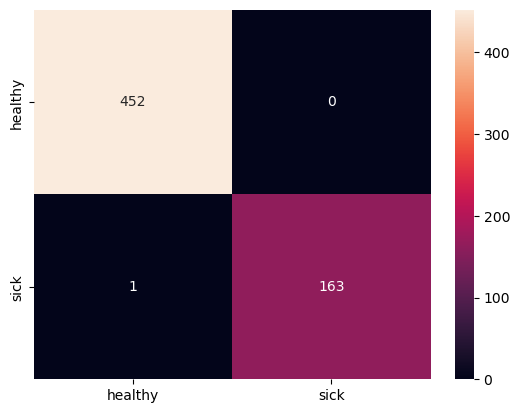

In [95]:
confutionMatrix = confusion_matrix(labels, predict)
sns.heatmap(confutionMatrix, annot=True, fmt='g', xticklabels=['healthy', 'sick'], yticklabels=['healthy', 'sick'])